In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime as dt
import yfinance as yf
import statsmodels.tsa.api as sm
import matplotlib.dates as mdates
import scipy.stats as stats


In [131]:
FCHI = yf.Ticker("^FCHI")
start_date = dt.datetime(2013, 2,1)
end_date = dt.datetime(2025, 3, 11)
FCHI_df = FCHI.history(start=start_date, end=end_date, auto_adjust=False)

In [132]:
FCHI_df['Log Returns'] = np.log(FCHI_df['Adj Close'] / FCHI_df['Adj Close'].shift(1))
FCHI_df['Squared Returns'] = FCHI_df['Log Returns'] ** 2

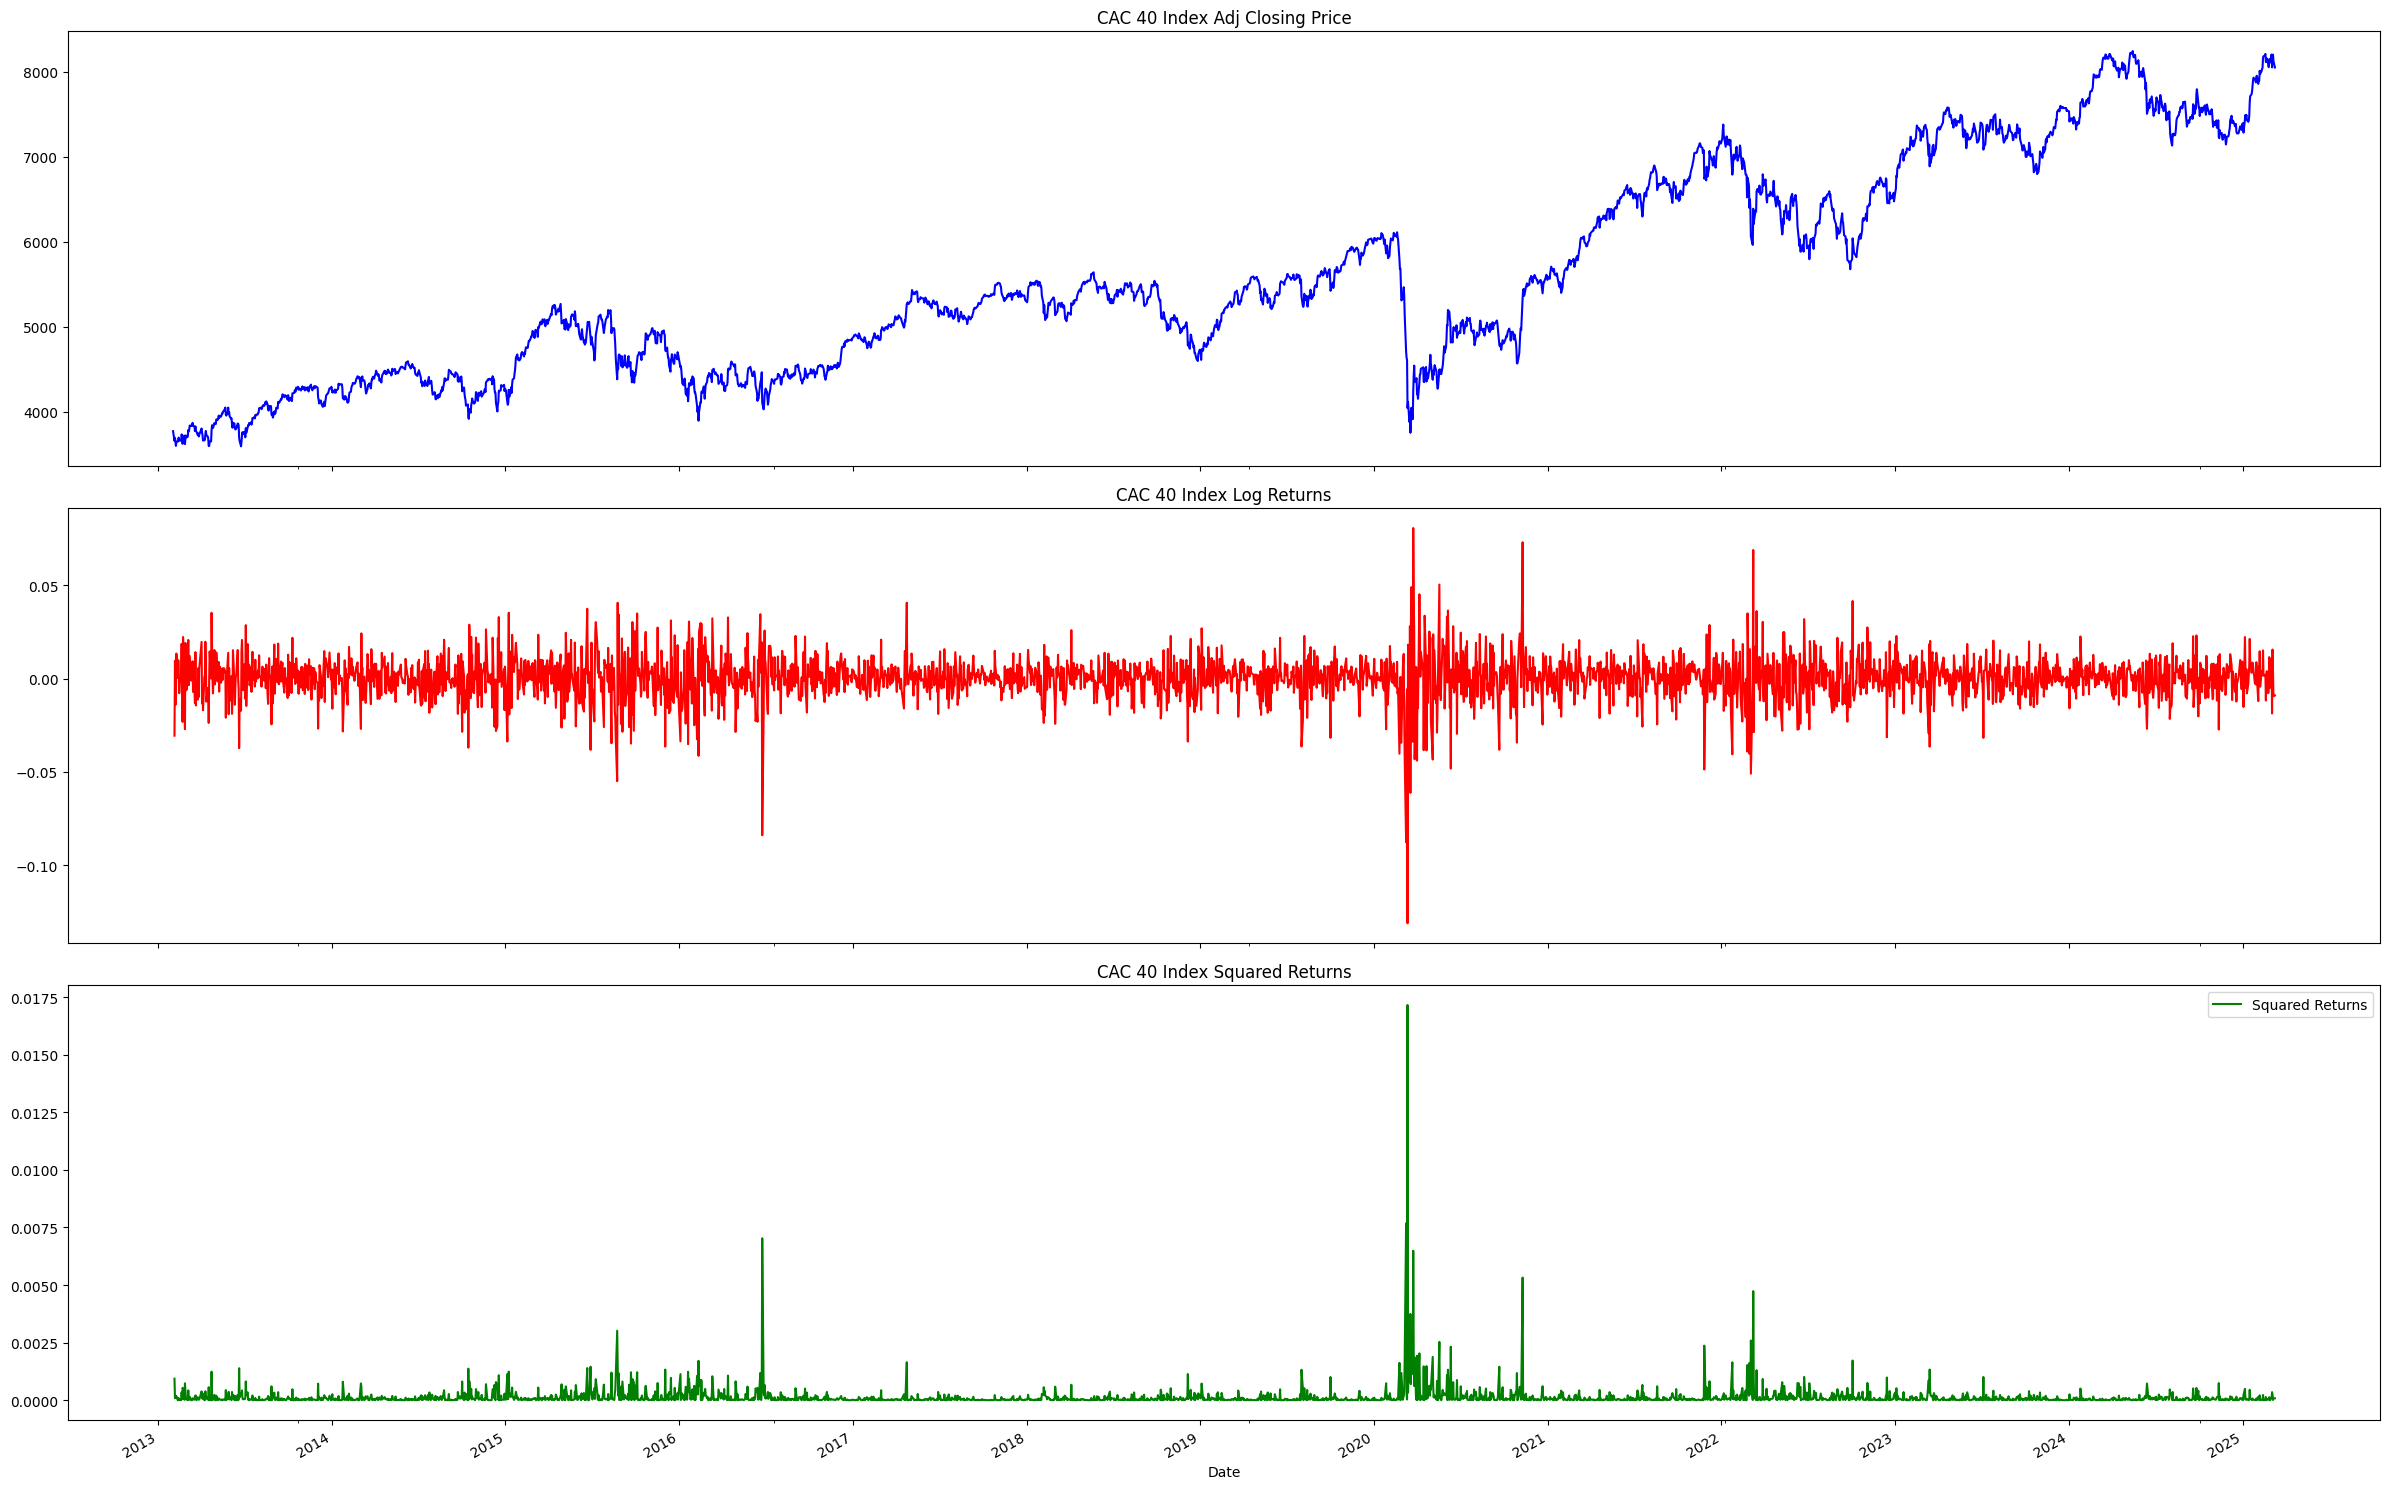

In [133]:
fig, axs = plt.subplots(3,1, figsize=(24, 15), sharex=True)
FCHI_df['Adj Close'].plot(ax=axs[0], title='CAC 40 Index Adj Closing Price', color='blue')
FCHI_df['Log Returns'].plot(ax=axs[1], title='CAC 40 Index Log Returns', color='red')
FCHI_df['Squared Returns'].plot(ax=axs[2], title='CAC 40 Index Squared Returns', color='green')

axs[0].xaxis.set_major_locator(mdates.YearLocator())
axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.legend()
plt.tight_layout()

In [134]:
def summary_statistic(series):
    mean = series.mean() * 100
    std = series.std(ddof=1) * 100
    skew = series.skew()
    kurt = series.kurtosis()
    summary = pd.DataFrame([mean, std, skew, kurt], index=['Mean (%)', 'Std (%)', 'Skew', 'Kurt'], columns=['Value'])
    return summary

summary = summary_statistic(FCHI_df['Log Returns'].dropna())
summary

,Value
Mean (%),0.024471
Std (%),1.156503
Skew,-0.794630
Kurt,10.627747


Text(42.347222222222214, 0.5, 'AutoCorrelation')

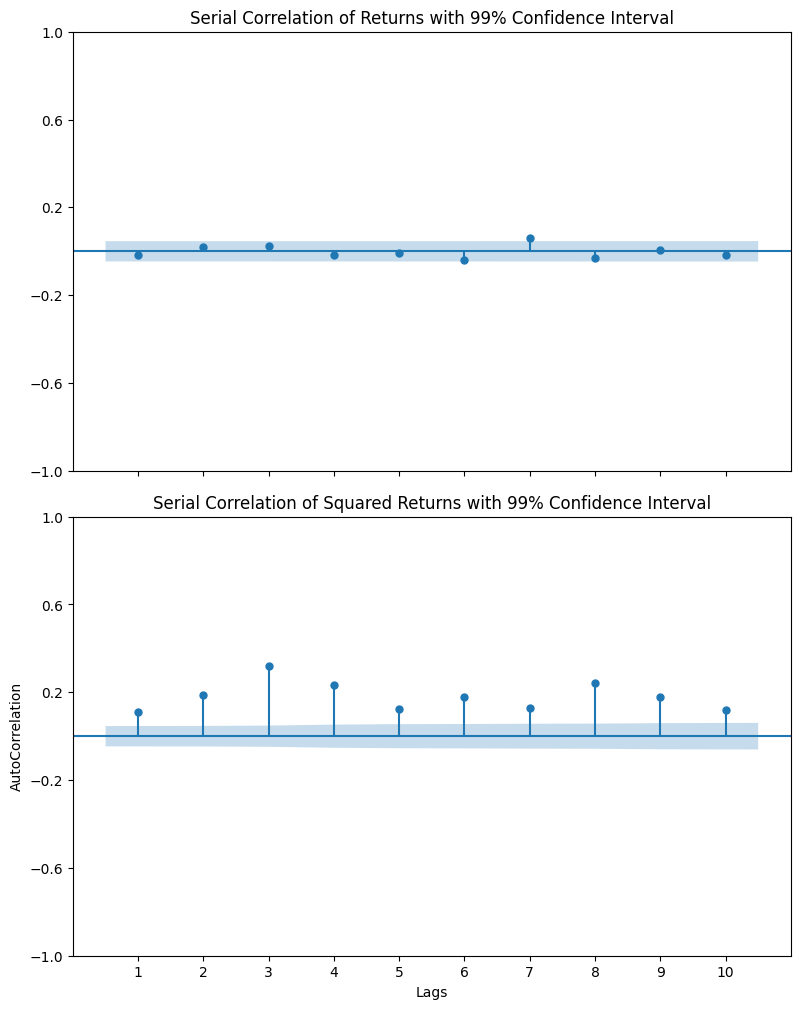

In [152]:
import statsmodels.graphics.tsaplots as sgt
fig, axs = plt.subplots(2,1, figsize =(8,10), sharex = True, sharey = True)
FCHI_acf = sm.acf(FCHI_df['Log Returns'].dropna(), nlags=10)
plot_acf_returns = sgt.plot_acf(FCHI_df['Log Returns'].dropna(), ax=axs[0], lags=10, alpha = 0.01, title='Serial Correlation of Returns with 99% Confidence Interval', zero=False)
plot_acf_squared_returns = sgt.plot_acf(FCHI_df['Squared Returns'].dropna(), lags=10, ax=axs[1], alpha = 0.01, title='Serial Correlation of Squared Returns with 99% Confidence Interval', zero=False)
plt.tight_layout()
plt.yticks(np.linspace(-1, 1, 6))
plt.xlabel('Lags')
plt.xticks(np.linspace(1,10,10))
plt.ylabel('AutoCorrelation')

AttributeError: Rectangle.set() got an unexpected keyword argument 'normalize'

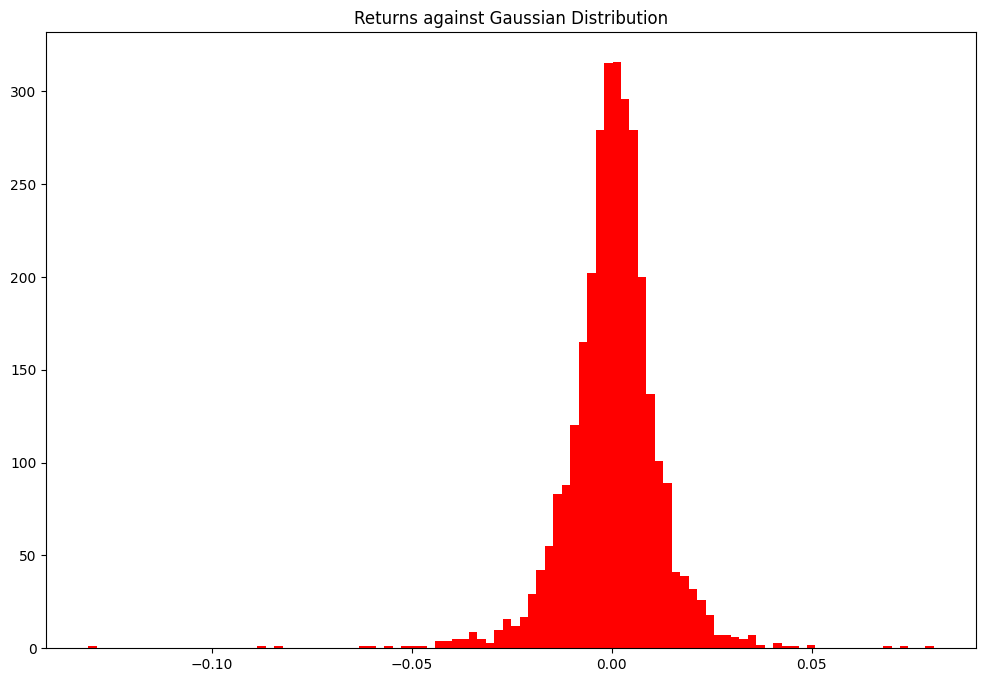

In [178]:
fig, axs = plt.subplots(1, figsize=(12,8))
plt.title('Returns against Gaussian Distribution')
FCHI_df['Log Returns'].hist(ax=axs, bins=100, color='red', label='Histogram of Log Returns', normalize=True)

mean = summary.loc['Mean (%)']['Value'] / 100
std = summary.loc['Std (%)']['Value'] / 100
x= np.linspace(mean - 5*std, mean + 5*std, len(FCHI_df['Log Returns']))
plt.plot(x, stats.norm.pdf(x, mean, std), color='blue', label='Gaussian Distribution')
plt.legend()


In [ ]:
FCHI_df['Log Returns'].value_counts(normalize=True).plot(kind='bar', figsize=(12,8), color='red', title='Frequency of Log Returns')

<Axes: title={'center': 'Frequency of Log Returns'}, xlabel='Log Returns'>